In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#  1. Open a video file

In [2]:
video_path = "/kaggle/input/notebooks/shawon10/object-detection-from-a-traffic-video/traffic_monitor.mp4"
cap = cv.VideoCapture(video_path)

# 2. Read first frame

In [3]:
ret, frame = cap.read()
if not ret:
    print("failed to read the file")
    exit()

# 3. Prepare first frame

In [4]:
prev_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
prev_gray = cv.GaussianBlur(prev_gray, (9,9), 0)

# 4. Starting the while loop

In [5]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

# 5. Convert current frame to grayscale and blur

In [6]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Convert current frame to grayscale and blur
    current_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    current_gray = cv.GaussianBlur(current_gray, (9,9), 0)

# 6. Compute difference


In [7]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    current_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    current_gray = cv.GaussianBlur(current_gray, (9,9), 0)

    # Compute difference
    diff = cv.absdiff(prev_gray, current_gray)

# 7. Thresholding

In [8]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    current_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    current_gray = cv.GaussianBlur(current_gray, (9,9), 0)

    diff = cv.absdiff(prev_gray, current_gray)

    # Thresholding
    _, motion_mask = cv.threshold(diff, 127, 255, cv.THRESH_BINARY)    

# 8. Finding contours

In [9]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    current_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    current_gray = cv.GaussianBlur(current_gray, (9,9), 0)

    diff = cv.absdiff(prev_gray, current_gray)

    # Thresholding
    _, motion_mask = cv.threshold(diff, 127, 255, cv.THRESH_BINARY)   

    # Finding contours
    contours,_ = cv.findcontours(
        motion_mask,
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_SIMPLE
    )

# 9. Drawing boxes

In [10]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    current_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    current_gray = cv.GaussianBlur(current_gray, (9,9), 0)

    diff = cv.absdiff(prev_gray, current_gray)

    # Thresholding
    _, motion_mask = cv.threshold(diff, 127, 255, cv.THRESH_BINARY)   

    # Finding contours
    contours,_ = cv.findcontours(
        motion_mask,
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_SIMPLE
    )

    for cnt in contour:
        area = cv.contourArea(cnt)
        if area < 500:
            continue
            
    # Drawing boxes
    x, y, w, h = cv.boundingRect(cnt)

    cv.rectangle(
        frame,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        3
    )

    plt.imshow(frame)

    # Update previous frame
    prev_gray = current_gray 

    break

cap.release()

# Full code snippet

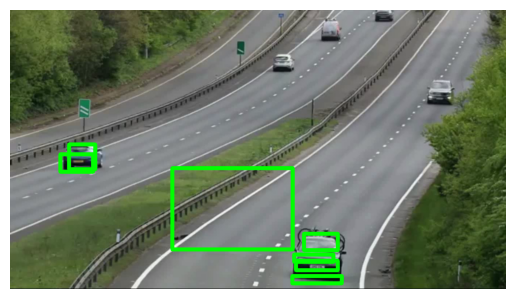

In [11]:
video_path = "/kaggle/input/datasets/nazaninashrafi/road-traffic-video-monitoring/british_highway_traffic.mp4"
cap = cv.VideoCapture(video_path)

ret, frame = cap.read()
if not ret:
    print("failed to read the file")
    exit()

prev_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
prev_gray = cv.GaussianBlur(prev_gray, (9,9), 0)


while True:
    ret, frame = cap.read()
    if not ret:
        break

    current_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    current_gray = cv.GaussianBlur(current_gray, (21,21), 0)

    diff = cv.absdiff(prev_gray, current_gray)

    # Thresholding
    _, motion_mask = cv.threshold(diff, 25, 255, cv.THRESH_BINARY)   

    # Finding contours
    contours,_ = cv.findContours(
        motion_mask,
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_SIMPLE
    )

    # Drawing boxes
    for cnt in contours:
        area = cv.contourArea(cnt)
        if area < 500:
            continue

        x, y, w, h = cv.boundingRect(cnt)
    
        cv.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            10
        )

    rgb_frame = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
    plt.imshow(rgb_frame)
    plt.axis("off")

    # Update previous frame
    prev_gray = current_gray 

    break


cap.release()

---

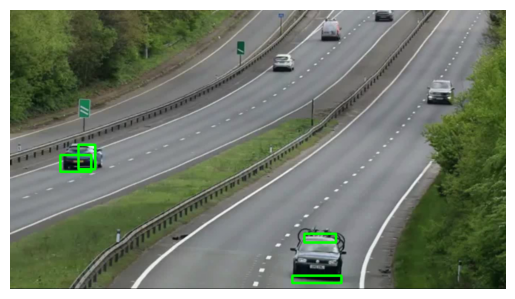

In [12]:
video_path = "/kaggle/input/datasets/nazaninashrafi/road-traffic-video-monitoring/british_highway_traffic.mp4"
cap = cv.VideoCapture(video_path)

ret, frame = cap.read()
if not ret:
    print("file does not exist")
# else:
#     rgb_frame = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
#     plt.imshow(rgb_frame)
#     plt.axis("off")

prev_frame = cv.cvtColor(frame,cv.COLOR_BGR2GRAY)
prev_frame = cv.GaussianBlur(prev_frame,(15,15),0)


while True:
    ret, frame = cap.read()
    if not ret:
        break

    current_frame = cv.cvtColor(frame,cv.COLOR_BGR2GRAY)
    current_frame = cv.GaussianBlur(current_frame,(21,21),0)

    diff = cv.absdiff(current_frame, prev_frame)

    _, motion_mask = cv.threshold(diff, 25, 255, cv.THRESH_BINARY)

    contours, _ = cv.findContours(
        motion_mask,       
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:
        area = cv.contourArea(cnt)
        if area < 500:
            continue

        x, y, w, h = cv.boundingRect(cnt)

        cv.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            (0, 255,0),
            5
        )

    rgb_frame = cv.cvtColor(frame,cv.COLOR_BGR2RGB)
    plt.imshow(rgb_frame)
    plt.axis("off")

    prev_frame = current_frame

    break

cap.release()


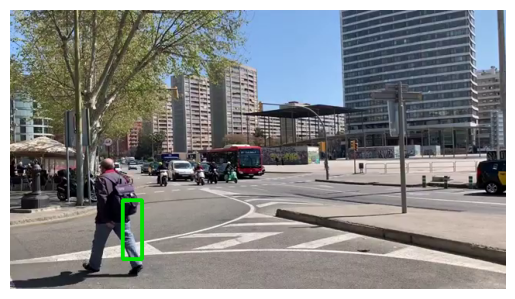

In [40]:
video_path = "/kaggle/input/datasets/nazaninashrafi/road-traffic-video-monitoring/road_trafifc.mp4"
cap = cv.VideoCapture(video_path)

ret, frame = cap.read()
if not ret:
    print("File does not exist")
else:
    prev_frame = cv.cvtColor(frame,cv.COLOR_BGR2GRAY)
    prev_frame = cv.GaussianBlur(prev_frame, (15,15), 0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    current_frame = cv.cvtColor(frame,cv.COLOR_BGR2GRAY)
    current_frame = cv.GaussianBlur(current_frame, (21,21), 0)

    diff = cv.absdiff(current_frame, prev_frame)

    _, motion_mask = cv.threshold(diff, 25, 255, cv.THRESH_BINARY)

    contours, _ = cv.findContours(
        motion_mask,       
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:
        if cv.contourArea(cnt) < 500:
            continue

        x,y,w,h = cv.boundingRect(cnt)

        cv.rectangle(
            frame,
            (x,y),
            (x+w, y+h),
            (0,225,0),
            4
        )

    rgb_frame = cv.cvtColor(frame,cv.COLOR_BGR2RGB)
    plt.imshow(rgb_frame)
    plt.axis("off")

    prev_frame = current_frame

    break


cap.release()

---

# Getting multiple frames

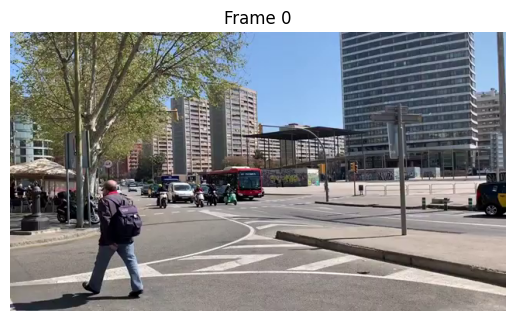

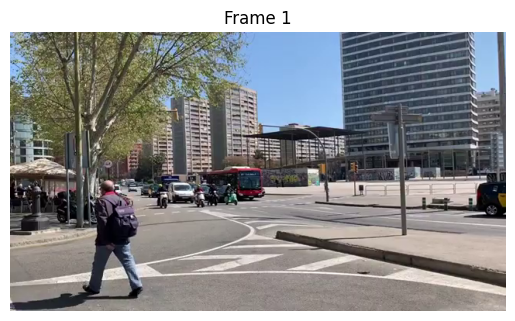

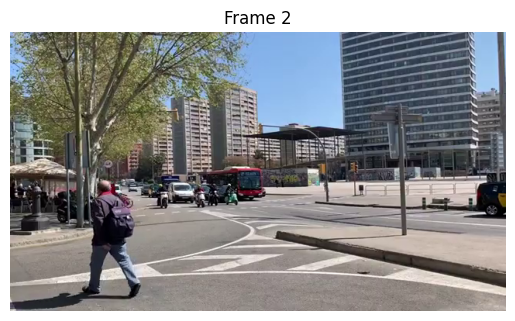

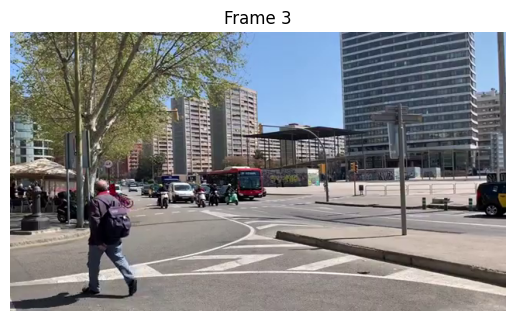

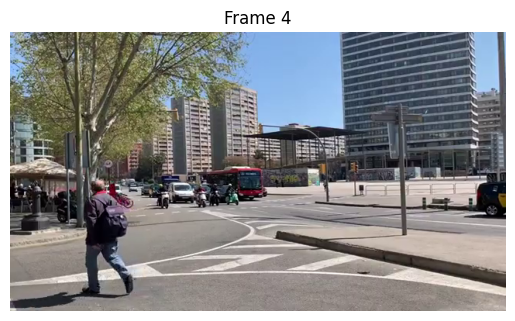

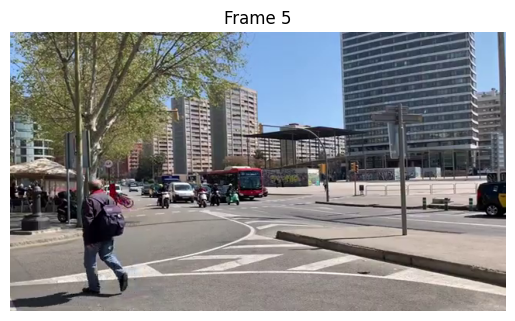

In [43]:
import cv2 as cv
import matplotlib.pyplot as plt

video_path = "/kaggle/input/datasets/nazaninashrafi/road-traffic-video-monitoring/road_trafifc.mp4"
cap = cv.VideoCapture(video_path)


num_frames = 5
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break


    rgb_frame = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
    plt.imshow(rgb_frame)
    plt.title(f"Frame {frame_count}")
    plt.axis("off")
    plt.show()

    if frame_count >= num_frames:
        break


    frame_count += 1

cap.release()

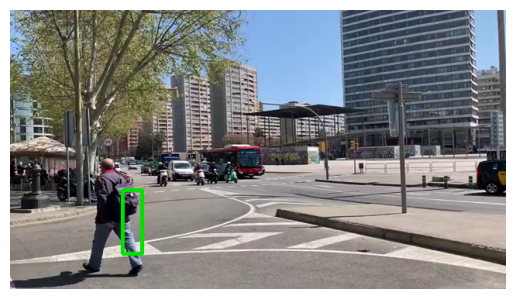

In [61]:
video_path = "/kaggle/input/datasets/nazaninashrafi/road-traffic-video-monitoring/road_trafifc.mp4"
cap = cv.VideoCapture(video_path)

ret, frame = cap.read()
if not ret:
    print("File does not exist")
else:
    prev_frame = cv.cvtColor(frame,cv.COLOR_BGR2GRAY)
    prev_frame = cv.GaussianBlur(prev_frame, (21,21), 0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    current_frame = cv.cvtColor(frame,cv.COLOR_BGR2GRAY)
    current_frame = cv.GaussianBlur(current_frame, (21,21), 0)

    diff = cv.absdiff(current_frame, prev_frame)

    _, motion_mask = cv.threshold(diff, 25, 255, cv.THRESH_BINARY)

    contours, _ = cv.findContours(
        motion_mask,       
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:
        if cv.contourArea(cnt) < 500:
            continue

        x,y,w,h = cv.boundingRect(cnt)

        cv.rectangle(
            frame,
            (x,y),
            (x+w, y+h),
            (0,225,0),
            4
        )

    rgb_frame = cv.cvtColor(frame,cv.COLOR_BGR2RGB)
    plt.imshow(rgb_frame)
    plt.axis("off")

    prev_frame = current_frame

    break


cap.release()

---

# # Getting multiple frames

## frame-to-frame motion

###  `while` loop

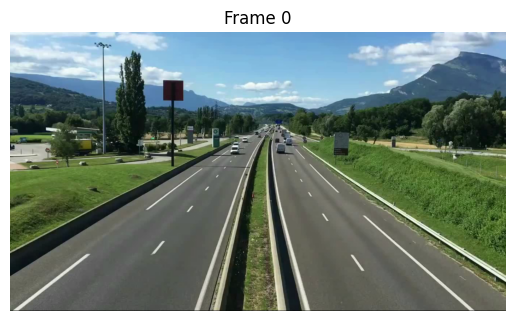

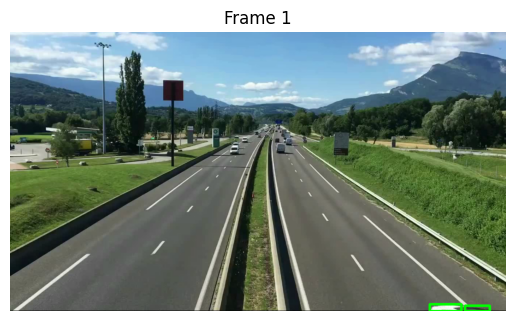

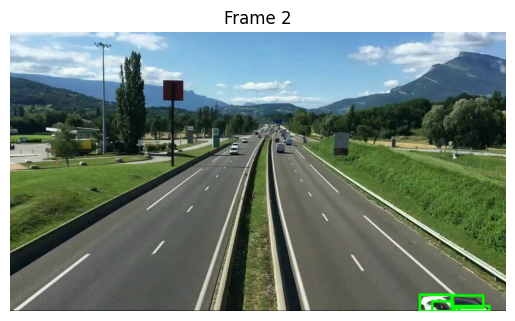

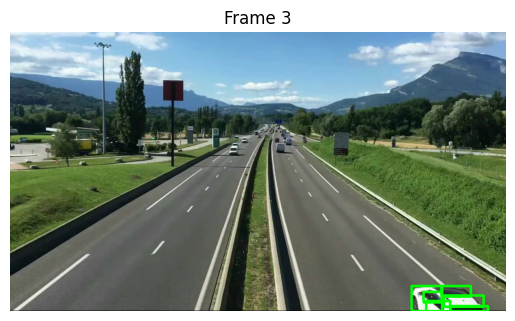

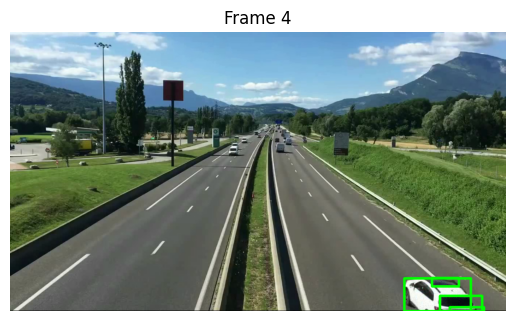

In [51]:
video_path = "/kaggle/input/datasets/nazaninashrafi/road-traffic-video-monitoring/traffic_video.avi"
cap = cv.VideoCapture(video_path)

num_frames = 5
frame_count = 0

ret, frame = cap.read()
if not ret:
    print("file does not exist")

prev_frame = cv.cvtColor(frame,cv.COLOR_BGR2GRAY)
prev_frame = cv.GaussianBlur(prev_frame,(15,15),0)


while True:
    if frame_count >= num_frames:
        break

    ret, frame = cap.read()
    if not ret:
        break

    current_frame = cv.cvtColor(frame,cv.COLOR_BGR2GRAY)
    current_frame = cv.GaussianBlur(current_frame,(21,21),0)

    diff = cv.absdiff(current_frame, prev_frame)

    _, motion_mask = cv.threshold(diff, 25, 255, cv.THRESH_BINARY)

    contours, _ = cv.findContours(
        motion_mask,       
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:
        area = cv.contourArea(cnt)
        if area < 500:
            continue

        x, y, w, h = cv.boundingRect(cnt)

        cv.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            (0, 255,0),
            5
        )

    rgb_frame = cv.cvtColor(frame,cv.COLOR_BGR2RGB)
    plt.imshow(rgb_frame)
    plt.title(f"Frame {frame_count}")
    plt.axis("off")
    plt.show()

    prev_frame = current_frame

    frame_count += 1

cap.release()


# Getting multiple frames 

### `enumerate()` function

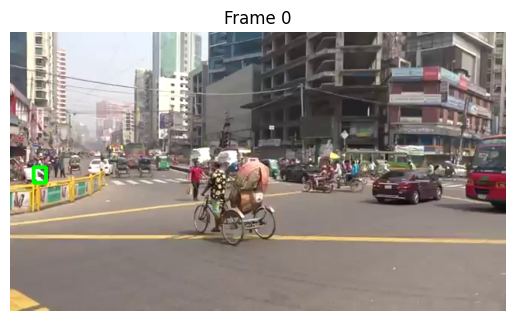

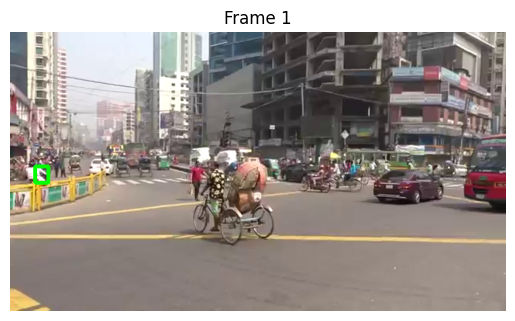

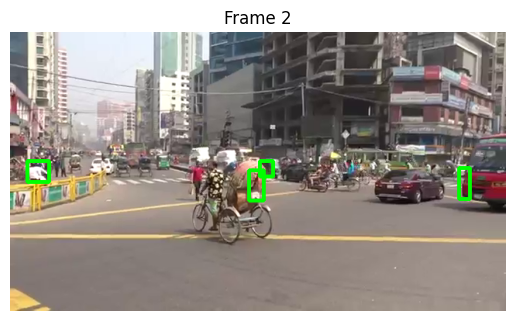

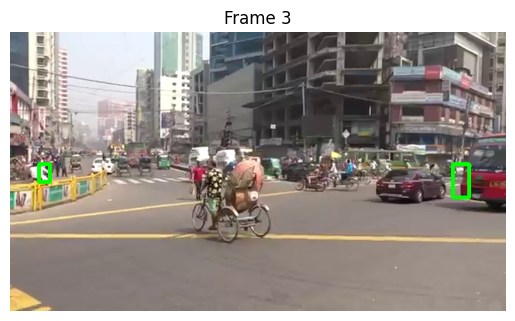

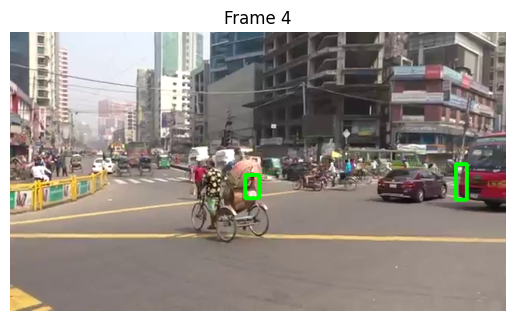

In [67]:
video_path = "/kaggle/input/datasets/nazaninashrafi/road-traffic-video-monitoring/dhaka_traffic.mp4"
cap = cv.VideoCapture(video_path)

ret, frame = cap.read()
if not ret:
    print("File does not exist")

prev_frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
prev_frame = cv.GaussianBlur(prev_frame, (21,21), 0)

num_frames = 5

for frame_idx, _ in enumerate(range(num_frames)):
    ret, frame = cap.read()
    if not ret:
        break

    current_frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    current_frame = cv.GaussianBlur(current_frame, (21,21), 0)

    diff = cv.absdiff(current_frame, prev_frame)
    _, motion_mask = cv.threshold(diff, 10, 255, cv.THRESH_BINARY)

    contours, _ = cv.findContours(
        motion_mask,
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:
        if cv.contourArea(cnt) < 200:
            continue

        x, y, w, h = cv.boundingRect(cnt)
        cv.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 4)

    rgb_frame = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
    plt.imshow(rgb_frame)
    plt.title(f"Frame {frame_idx}")
    plt.axis("off")
    plt.show()

    prev_frame = current_frame

cap.release()

# Getting multiple frames

## background reference method (fixed background frame)

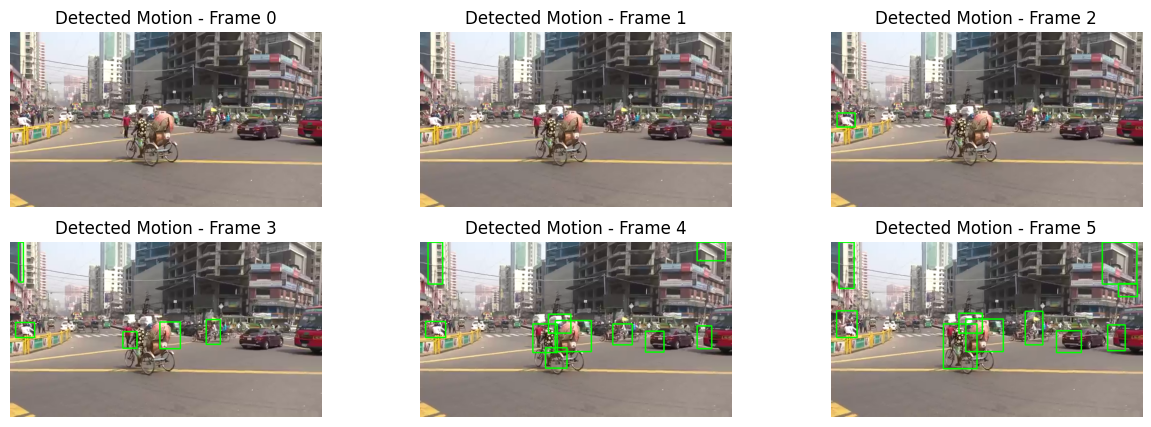

In [68]:
# 1. Initialize video capture
# On Kaggle, you would use a path to a .mp4 file in your /kaggle/input/ directory
video_path = '/kaggle/input/datasets/nazaninashrafi/road-traffic-video-monitoring/dhaka_traffic.mp4' 
cap = cv2.VideoCapture(video_path)

# Variables to store the background and a sample result
first_frame = None
output_frames = []

while len(output_frames) < 6:  # Just capture a few examples for visualization
    ret, frame = cap.read()
    if not ret:
        break

    # 2. Preprocessing
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (21, 21), 0)

    # Initialize the first frame as the background reference
    if first_frame is None:
        first_frame = gray
        continue

    # 3. Compute Difference
    # $||frame_i - frame_{first}||$
    delta_frame = cv2.absdiff(first_frame, gray)
    
    # 4. Thresholding
    # If a pixel change > 25, set it to 255 (white)
    thresh_frame = cv2.threshold(delta_frame, 25, 255, cv2.THRESH_BINARY)[1]
    thresh_frame = cv2.dilate(thresh_frame, None, iterations=2)

    # 5. Finding Contours
    contours, _ = cv2.findContours(thresh_frame.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for contour in contours:
        if cv2.contourArea(contour) < 500: # Ignore small movements like noise
            continue
        (x, y, w, h) = cv2.boundingRect(contour)
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

    output_frames.append(frame)

cap.release()

# 6. Display the result
plt.figure(figsize=(15, 5))
for i, img in enumerate(output_frames):
    plt.subplot(2, 3, i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected Motion - Frame {i}")
    plt.axis('off')
plt.show()

---